This code downloads wind data from ERA5.

In [1]:
import cdsapi

c = cdsapi.Client(
    url="https://cds.climate.copernicus.eu/api",
    key="1e9aa134-9779-4ac2-846f-2ab89b57873e"
)

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': [
            '10m_u_component_of_wind',
            '10m_v_component_of_wind',
        ],
        'year': [str(y) for y in range(2015, 2026)],
        'month': [f'{m:02d}' for m in range(1, 13)],
        'time': '00:00',
        'area': [6, 95, -11, 141],
        'format': 'netcdf',
        'grid': '0.25/0.25',
    },
    '/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/wind/era5_wind_indonesia_2015_2025.nc'
)

2026-06-11 10:32:33,471 INFO [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).


2026-06-11 10:32:34,070 INFO Request ID is cae87403-82d1-4879-a7b7-b8c5a43e3d1f


2026-06-11 10:32:34,260 INFO status has been updated to accepted


2026-06-11 10:32:56,206 INFO status has been updated to running


2026-06-11 10:33:07,770 INFO status has been updated to successful


...

89c9f887d919e74c1b95d60b5e91e5b8.nc:  14%|█▍        | 1.00M/7.24M [00:01<00:08, 784kB/s]

89c9f887d919e74c1b95d60b5e91e5b8.nc:  28%|██▊       | 2.00M/7.24M [00:01<00:03, 1.69MB/s]

89c9f887d919e74c1b95d60b5e91e5b8.nc:  55%|█████▌    | 4.00M/7.24M [00:01<00:00, 3.88MB/s]

89c9f887d919e74c1b95d60b5e91e5b8.nc: 100%|██████████| 7.24M/7.24M [00:01<00:00, 8.14MB/s]

'/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/wind/era5_wind_indonesia_2015_2025.nc'

## 1. Imports and configuration

All paths are relative to wherever you run the notebook. Set `DATA_DIR` to the folder containing your fire CSV and ACLED xlsx.

In [2]:
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pyfixest as pf
from pathlib import Path
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────
WIND_NC    = '/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/wind/era5_wind_indonesia_2015_2025.nc'
FIRE_CSV   = '/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/fire/DL_FIRE_SUOMI-VIIRS-C2_718931_Nov2000-Feb2026_buffer0km-csv/fire_archive_SV-C2_718931.csv'
ACLED_XLSX = '/Users/hariaksha/Documents/GitHub/climate-conflict/data/unrest/ACLED Data_2026-06-10.xlsx'

# ── Parameters ────────────────────────────────────────────────────────────
UPWIND_RADIUS_KM  = 300   # search radius for upwind fires
UPWIND_HALF_ANG   = 45    # ± degrees from upwind direction
START_YEAR        = 2015
END_YEAR          = 2025
END_MONTH         = 6
N_LAGS            = 1 # controls how many monthly lags of fire exposure to include as additional regressors in model
PROV_BUFFER       = 0.5   # degrees added to province bounding boxes
R_EARTH           = 6371.0  # km, for distance conversions

POLITICAL_VIOLENCE = [
    'Riots', 'Violence against civilians',
    'Battles', 'Explosions/Remote violence',
]

print('All imports OK')

All imports OK


## 2. Load ERA5 wind data and compute wind direction

ERA5 provides:
- **u10**: eastward (positive = blowing east)
- **v10**: northward (positive = blowing north)

We derive the direction the wind is **blowing from** (meteorological convention, degrees clockwise from north), and wind speed. These are aggregated to province level by averaging over grid cells within each province's bounding box.

In [3]:
ds = xr.open_dataset(WIND_NC)
print('Wind dataset variables:', list(ds.data_vars))
print('Dimensions:', dict(ds.dims))
print('Time range:', ds.valid_time.values[[0, -1]] if 'valid_time' in ds
      else ds.time.values[[0, -1]])

# Normalise dimension names
if 'valid_time' in ds.coords:
    ds = ds.rename({'valid_time': 'time'})

# Pull u and v arrays
u_da = ds['u10'] if 'u10' in ds else ds[list(ds.data_vars)[0]]
v_da = ds['v10'] if 'v10' in ds else ds[list(ds.data_vars)[1]]

# Convert to dataframe
u_df = u_da.to_dataframe(name='u10').reset_index()
v_df = v_da.to_dataframe(name='v10').reset_index()
wind_df = u_df.merge(v_df, on=['time', 'latitude', 'longitude'])

# Parse year/month
wind_df['time'] = pd.to_datetime(wind_df['time'])
wind_df['year']  = wind_df['time'].dt.year
wind_df['month'] = wind_df['time'].dt.month
wind_df = wind_df[(wind_df['year'] >= START_YEAR) &
                   ~((wind_df['year'] == END_YEAR) & (wind_df['month'] > END_MONTH))]

# Wind speed and direction
wind_df['wind_speed']    = np.sqrt(wind_df['u10']**2 + wind_df['v10']**2)
wind_df['wind_dir_from'] = (np.degrees(np.arctan2(wind_df['u10'],
                                                    wind_df['v10'])) + 180) % 360

print(f'\nWind grid points per month: {wind_df.groupby(["year","month"]).size().mean():.0f}')
print(f'Wind speed  — mean: {wind_df.wind_speed.mean():.2f} m/s  '
      f'max: {wind_df.wind_speed.max():.2f} m/s')
print(wind_df[['latitude','longitude','year','month',
               'u10','v10','wind_speed','wind_dir_from']].head())

Wind dataset variables: ['u10', 'v10']
Dimensions: {'valid_time': 132, 'latitude': 69, 'longitude': 185}
Time range: ['2015-01-01T00:00:00.000000000' '2025-12-01T00:00:00.000000000']



Wind grid points per month: 12765
Wind speed  — mean: 2.85 m/s  max: 10.25 m/s
   latitude  longitude  year  month       u10       v10  wind_speed  \
0       6.0      95.00  2015      1 -5.425678 -0.700418    5.470701   
1       6.0      95.25  2015      1 -5.431049 -0.367411    5.443463   
2       6.0      95.50  2015      1 -5.124897  0.068624    5.125357   
3       6.0      95.75  2015      1 -4.750385  0.175558    4.753628   
4       6.0      96.00  2015      1 -4.547749  0.045187    4.547973   

   wind_dir_from  
0      82.644188  
1      86.129837  
2      90.767174  
3      92.116501  
4      90.569283  


## 3. Load ACLED conflict data

We aggregate events to province-month for two outcomes:
- **events**: all ACLED event types
- **pv_events**: political violence only (riots, battles, violence against civilians, explosions)

Province bounding boxes derived from ACLED coordinates are used to assign fire detections and wind grid cells to provinces. For production, replace with a BPS administrative shapefile.

In [4]:
acled = pd.read_excel(
    ACLED_XLSX,
    usecols=['event_date','admin1','event_type','fatalities',
             'latitude','longitude']
)
acled['event_date'] = pd.to_datetime(acled['event_date'])
acled['year']       = acled['event_date'].dt.year
acled['month']      = acled['event_date'].dt.month
acled['is_pv']      = acled['event_type'].isin(POLITICAL_VIOLENCE)

conflict_pm = (
    acled.groupby(['admin1','year','month'])
    .agg(events=('event_type','count'),
         pv_events=('is_pv','sum'),
         fatalities=('fatalities','sum'))
    .reset_index()
)

# Province bounding boxes
prov_bounds = (
    acled.groupby('admin1')
    .agg(lat_min=('latitude','min'), lat_max=('latitude','max'),
         lon_min=('longitude','min'), lon_max=('longitude','max'))
    .reset_index()
)
prov_bounds['lat_min'] -= PROV_BUFFER
prov_bounds['lat_max'] += PROV_BUFFER
prov_bounds['lon_min'] -= PROV_BUFFER
prov_bounds['lon_max'] += PROV_BUFFER
prov_bounds['bbox_area'] = (
    (prov_bounds['lat_max'] - prov_bounds['lat_min']) *
    (prov_bounds['lon_max'] - prov_bounds['lon_min'])
)

# Province centroids (used for upwind search)
prov_centroids = prov_bounds.copy()
prov_centroids['prov_lat'] = (prov_bounds['lat_min'] + prov_bounds['lat_max']) / 2
prov_centroids['prov_lon'] = (prov_bounds['lon_min'] + prov_bounds['lon_max']) / 2

print(f'Provinces: {acled["admin1"].nunique()}')
print(f'All events: {len(acled):,}  |  '
      f'Political violence: {acled["is_pv"].sum():,} '
      f'({acled["is_pv"].mean()*100:.1f}%)')
print(conflict_pm.head())

Provinces: 38
All events: 21,703  |  Political violence: 3,546 (16.3%)
  admin1  year  month  events  pv_events  fatalities
0   Aceh  2015      1       3          1           0
1   Aceh  2015      2       1          0           0
2   Aceh  2015      3       4          3           6
3   Aceh  2015      4       1          0           0
4   Aceh  2015      5       6          4           4


## 4. Load and filter fire data

Filters applied:
- `type == 0`: vegetation fires only (drops volcanoes, industrial heat sources)
- `confidence in ['h', 'n']`: high and nominal confidence only (drops low-confidence detections)

Each fire detection retains its exact lat/lon, which is needed for the upwind instrument construction in the next step.

In [5]:
fires_raw = pd.read_csv(
    FIRE_CSV,
    usecols=['acq_date','latitude','longitude','frp','confidence','type'],
    dtype={'confidence': str, 'type': int}
)
print(f'Raw detections: {len(fires_raw):,}')

fires = fires_raw[
    (fires_raw['type'] == 0) &
    (fires_raw['confidence'].isin(['h','n']))
].copy()
print(f'After type=0 and confidence h/n: {len(fires):,} '
      f'({len(fires)/len(fires_raw)*100:.1f}% retained)')

fires['acq_date'] = pd.to_datetime(fires['acq_date'])
fires['year']     = fires['acq_date'].dt.year
fires['month']    = fires['acq_date'].dt.month
fires = fires[
    (fires['year'] >= START_YEAR) &
    ~((fires['year'] == END_YEAR) & (fires['month'] > END_MONTH))
]
print(f'After date filter: {len(fires):,}')

# Assign fires to provinces
lat_arr    = fires['latitude'].values
lon_arr    = fires['longitude'].values
p_names    = prov_bounds['admin1'].values
lat_mins   = prov_bounds['lat_min'].values
lat_maxs   = prov_bounds['lat_max'].values
lon_mins   = prov_bounds['lon_min'].values
lon_maxs   = prov_bounds['lon_max'].values
bbox_areas = prov_bounds['bbox_area'].values

assigned = []
for la, lo in zip(lat_arr, lon_arr):
    mask = ((lat_mins<=la)&(la<=lat_maxs)&
            (lon_mins<=lo)&(lo<=lon_maxs))
    if not mask.any():
        assigned.append(None)
    else:
        idxs = np.where(mask)[0]
        assigned.append(p_names[idxs[np.argmin(bbox_areas[idxs])]])

fires['admin1'] = assigned
fires = fires.dropna(subset=['admin1'])

# Province-month fire totals (the endogenous treatment variable)
fires_pm = (
    fires.groupby(['admin1','year','month'])
    .agg(n_fires=('frp','size'), total_frp=('frp','sum'))
    .reset_index()
)
fires_pm['log_frp']     = np.log1p(fires_pm['total_frp'])
fires_pm['log_n_fires'] = np.log1p(fires_pm['n_fires'])

print(f'\nProvince-month fire obs: {len(fires_pm):,}')
print(f'Provinces with fire:     {fires_pm["admin1"].nunique()}')

Raw detections: 3,514,520


After type=0 and confidence h/n: 3,140,194 (89.3% retained)


After date filter: 2,038,664



Province-month fire obs: 4,680
Provinces with fire:     38


## 5. Aggregate wind to province level

For each province-month, compute the mean u10 and v10 over all grid cells falling within the province's bounding box. This gives the representative wind direction and speed for that province in that month.

In [6]:
prov_wind_rows = []
for _, pb in prov_bounds.iterrows():
    mask = (
        (wind_df['latitude']  >= pb['lat_min']) &
        (wind_df['latitude']  <= pb['lat_max']) &
        (wind_df['longitude'] >= pb['lon_min']) &
        (wind_df['longitude'] <= pb['lon_max'])
    )
    sub = wind_df[mask].groupby(['year','month']).agg(
        u10_mean=('u10','mean'), v10_mean=('v10','mean')).reset_index()
    sub['admin1'] = pb['admin1']
    prov_wind_rows.append(sub)

prov_wind = pd.concat(prov_wind_rows, ignore_index=True)
prov_wind['wind_speed']    = np.sqrt(prov_wind['u10_mean']**2 +
                                      prov_wind['v10_mean']**2)
prov_wind['wind_dir_from'] = (
    np.degrees(np.arctan2(prov_wind['u10_mean'],
                           prov_wind['v10_mean'])) + 180
) % 360

print(f'Province-month wind obs: {len(prov_wind):,}')
print('Sample:')
print(prov_wind.head())

Province-month wind obs: 4,788
Sample:
   year  month  u10_mean  v10_mean admin1  wind_speed  wind_dir_from
0  2015      1 -0.926375  0.032194   Aceh    0.926934      91.990364
1  2015      2 -0.825625 -0.200280   Aceh    0.849570      76.364624
2  2015      3 -0.306152 -0.110757   Aceh    0.325570      70.111252
3  2015      4 -0.032030  0.057876   Aceh    0.066147     151.038879
4  2015      5  0.106618  0.318143   Aceh    0.335533     198.527405


## 6. Construct the wind instrument: upwind fire exposure (VECTORISED)

**Instrument definition:** For each province $p$ in month $t$, sum the FRP of all individual fire detections that:
1. Fall within `UPWIND_RADIUS_KM` of the province centroid, **and**
2. Lie within ±`UPWIND_HALF_ANG`° of the direction the wind is blowing **from**

$$Z_{pt} = \sum_{f \in \mathcal{U}_{pt}} \text{FRP}_f$$

where $\mathcal{U}_{pt}$ is the set of fire detections upwind of province $p$ in month $t$.

**Speedup:** We use `scipy.spatial.cKDTree` to index fire coordinates and query for fires within radius, rather than checking all 17,000 fires against each province. This reduces runtime from ~10 minutes to under 1 minute while producing identical results.

**Identification logic:**
- Wind direction in a given month is driven by large-scale atmospheric circulation (monsoon system, ENSO phase) — plausibly exogenous to local conflict
- Fires that happen to be burning upwind of a province are more likely to expose that province to smoke, heat displacement, and economic disruption
- This gives an exogenous source of variation in fire exposure

**Exclusion restriction assumption:** Wind direction affects conflict *only through* fire exposure, not through independent channels such as agricultural productivity or rainfall. This is the key assumption to defend in the paper.

In [7]:
def haversine_vectorised(lat1, lon1, lat2_arr, lon2_arr):
    """Distance in km from one point to an array of points."""
    dlat = np.radians(lat2_arr - lat1)
    dlon = np.radians(lon2_arr - lon1)
    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2_arr)) *
         np.sin(dlon/2)**2)
    return R_EARTH * 2 * np.arcsin(np.sqrt(a))


def bearing_to(lat1, lon1, lat2_arr, lon2_arr):
    """Bearing (degrees, 0=N, clockwise) from point 1 to each point in array."""
    dlon = np.radians(lon2_arr - lon1)
    x = np.sin(dlon) * np.cos(np.radians(lat2_arr))
    y = (np.cos(np.radians(lat1)) * np.sin(np.radians(lat2_arr)) -
         np.sin(np.radians(lat1)) * np.cos(np.radians(lat2_arr)) * np.cos(dlon))
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


def angular_diff(a, b):
    """Smallest absolute angular difference between two angles (degrees)."""
    return np.minimum(np.abs(a - b) % 360, 360 - np.abs(a - b) % 360)


def lat_lon_to_cartesian(lat, lon):
    """Convert lat/lon to 3D Cartesian coordinates on unit sphere.
    
    This conversion is necessary for accurate spatial indexing near the equator,
    where Euclidean distance in lat/lon space is distorted.
    """
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack([x, y, z])


# VECTORISED INSTRUMENT CONSTRUCTION
# Build spatial index from fire coordinates
print('Building spatial index from fire detections...')
fire_lats = fires['latitude'].values
fire_lons = fires['longitude'].values
fire_frps = fires['frp'].values
fire_years = fires['year'].values
fire_months = fires['month'].values

# Convert to 3D Cartesian for efficient distance queries
fire_cart = lat_lon_to_cartesian(fire_lats, fire_lons)
fire_tree = cKDTree(fire_cart)
print(f'  Spatial index built: {len(fire_lats):,} detections')

# Build instrument for each province-month
instrument_rows = []
n_prov_months = len(prov_wind)

for i, (_, pw) in enumerate(prov_wind.iterrows()):
    if (i + 1) % 500 == 0:
        print(f'  Progress: {i+1:,}/{n_prov_months:,}')
    
    pname = pw['admin1']
    yr    = int(pw['year'])
    mo    = int(pw['month'])
    wdir  = pw['wind_dir_from']
    
    # Province centroid in Cartesian coordinates
    pc = prov_centroids[prov_centroids['admin1'] == pname].iloc[0]
    clat, clon = pc['prov_lat'], pc['prov_lon']
    c_cart = lat_lon_to_cartesian(np.array([clat]), np.array([clon]))[0]
    
    # Query tree for all fires within radius
    # Convert km to chord distance: d = 2*R*sin(theta/2), where theta = distance/R
    radius_radians = UPWIND_RADIUS_KM / R_EARTH
    max_chord = 2 * np.sin(radius_radians / 2)
    
    fire_indices = fire_tree.query_ball_point(c_cart, max_chord)
    
    if not fire_indices:
        instrument_rows.append({
            'admin1': pname, 'year': yr, 'month': mo,
            'upwind_frp': 0.0, 'n_upwind_fires': 0
        })
        continue
    
    # Filter by month
    fire_indices = np.array(fire_indices)
    month_mask = (fire_years[fire_indices] == yr) & (fire_months[fire_indices] == mo)
    month_indices = fire_indices[month_mask]
    
    if len(month_indices) == 0:
        instrument_rows.append({
            'admin1': pname, 'year': yr, 'month': mo,
            'upwind_frp': 0.0, 'n_upwind_fires': 0
        })
        continue
    
    # Get fire data for this month
    f_lats = fire_lats[month_indices]
    f_lons = fire_lons[month_indices]
    f_frps = fire_frps[month_indices]
    
    # Verify distances with haversine (safety check)
    dists = haversine_vectorised(clat, clon, f_lats, f_lons)
    dist_mask = dists <= UPWIND_RADIUS_KM
    
    if not dist_mask.any():
        instrument_rows.append({
            'admin1': pname, 'year': yr, 'month': mo,
            'upwind_frp': 0.0, 'n_upwind_fires': 0
        })
        continue
    
    # Filter by distance and wind direction
    f_lats_near = f_lats[dist_mask]
    f_lons_near = f_lons[dist_mask]
    f_frps_near = f_frps[dist_mask]
    
    bearings = bearing_to(clat, clon, f_lats_near, f_lons_near)
    ang_diff = angular_diff(bearings, wdir)
    upwind_mask = ang_diff <= UPWIND_HALF_ANG
    
    instrument_rows.append({
        'admin1':         pname,
        'year':           yr,
        'month':          mo,
        'upwind_frp':     float(f_frps_near[upwind_mask].sum()),
        'n_upwind_fires': int(upwind_mask.sum()),
    })

instrument_df = pd.DataFrame(instrument_rows)
instrument_df['log_upwind_frp'] = np.log1p(instrument_df['upwind_frp'])

print(f'\nInstrument construction complete!')
print(f'Instrument obs: {len(instrument_df):,}')
print(f'Zero-upwind-fire months: {(instrument_df["upwind_frp"]==0).mean()*100:.1f}%')
print('\nInstrument (log_upwind_frp) summary:')
print(instrument_df['log_upwind_frp'].describe().round(3))

Building spatial index from fire detections...


  Spatial index built: 2,021,347 detections


  Progress: 500/4,788


  Progress: 1,000/4,788


  Progress: 1,500/4,788


...

  Progress: 3,000/4,788


  Progress: 3,500/4,788


  Progress: 4,000/4,788


  Progress: 4,500/4,788



Instrument construction complete!
Instrument obs: 4,788
Zero-upwind-fire months: 7.8%

Instrument (log_upwind_frp) summary:
count    4788.000
mean        4.717
std         2.437
min         0.000
25%         3.158
50%         4.813
75%         6.378
max        13.313
Name: log_upwind_frp, dtype: float64


## 7. Build the full IV panel

The panel is balanced across all province-months in 2015–June 2025. It contains:
- **Outcomes**: `events` (all), `pv_events` (political violence)
- **Treatment**: `log_frp` (endogenous, province-month fire intensity)
- **Instrument**: `log_upwind_frp` (exogenous upwind fire exposure)
- **Fixed effects**: province (`admin1`) and year-month (`year_month`)
- **Lags**: 6 monthly lags of treatment and instrument

The structural equation being estimated is:

$$E[Y_{pt}] = \exp\left(\alpha_p + \gamma_t + \sum_{k=0}^{6} \beta_k \widehat{\text{logFRP}}_{p,t-k}\right)$$

where $\widehat{\text{logFRP}}$ is the fire intensity instrumented by upwind fire exposure.

In [8]:
all_provs = conflict_pm['admin1'].unique()
all_ym    = pd.DataFrame(
    [(y, m) for y in range(START_YEAR, END_YEAR + 1)
     for m in range(1, 13)
     if not (y == END_YEAR and m > END_MONTH)],
    columns=['year','month']
)

panel = pd.merge(pd.DataFrame({'admin1': all_provs}), all_ym, how='cross')

# Merge outcomes
panel = panel.merge(conflict_pm, on=['admin1','year','month'], how='left')
panel['events']     = panel['events'].fillna(0).astype(int)
panel['pv_events']  = panel['pv_events'].fillna(0).astype(int)
panel['fatalities'] = panel['fatalities'].fillna(0).astype(int)

# Merge treatment
panel = panel.merge(
    fires_pm[['admin1','year','month','log_frp','log_n_fires']],
    on=['admin1','year','month'], how='left'
)
panel['log_frp']     = panel['log_frp'].fillna(0)
panel['log_n_fires'] = panel['log_n_fires'].fillna(0)

# Merge instrument
panel = panel.merge(
    instrument_df[['admin1','year','month','log_upwind_frp']],
    on=['admin1','year','month'], how='left'
)
panel['log_upwind_frp'] = panel['log_upwind_frp'].fillna(0)

# Merge wind covariates
panel = panel.merge(
    prov_wind[['admin1','year','month','wind_speed','wind_dir_from']],
    on=['admin1','year','month'], how='left'
)

# Build lags for treatment and instrument
panel = panel.sort_values(['admin1','year','month']).reset_index(drop=True)
for lag in range(1, N_LAGS + 1):
    panel[f'log_frp_l{lag}']        = panel.groupby('admin1')['log_frp'].shift(lag)
    panel[f'log_upwind_frp_l{lag}'] = panel.groupby('admin1')['log_upwind_frp'].shift(lag)

lag_frp_cols    = [f'log_frp_l{l}'        for l in range(1, N_LAGS + 1)]
lag_upwind_cols = [f'log_upwind_frp_l{l}' for l in range(1, N_LAGS + 1)]
panel = panel.dropna(subset=lag_frp_cols + lag_upwind_cols).reset_index(drop=True)
panel['year_month'] = panel['year'] * 100 + panel['month']

print(f'Panel: {len(panel):,} obs  |  '
      f'{panel["admin1"].nunique()} provinces  |  '
      f'{panel["year_month"].nunique()} time periods')
print(f'Zero-event share (all events):        {(panel["events"]==0).mean()*100:.1f}%')
print(f'Zero-event share (political violence): {(panel["pv_events"]==0).mean()*100:.1f}%')
print(f'\nInstrument coverage (non-zero upwind FRP): '
      f'{(panel["log_upwind_frp"]>0).mean()*100:.1f}%')
print(f'Corr(log_frp, log_upwind_frp): '
      f'{panel["log_frp"].corr(panel["log_upwind_frp"]):.3f}')

Panel: 4,750 obs  |  38 provinces  |  125 time periods
Zero-event share (all events):        28.4%
Zero-event share (political violence): 67.4%

Instrument coverage (non-zero upwind FRP): 92.3%
Corr(log_frp, log_upwind_frp): 0.732


## 8. First stage: instrument relevance

Before running the IV, we must verify the instrument is **relevant** — i.e. that upwind fire exposure is a strong predictor of actual provincial fire intensity after conditioning on fixed effects.

We estimate:
$$\text{logFRP}_{pt} = \alpha_p + \gamma_t + \delta_0 Z_{pt} + \sum_{k=1}^{6} \delta_k Z_{p,t-k} + \eta_{pt}$$

The key diagnostics are:
- **F-statistic on excluded instruments** (Montiel Olea-Pflueger robust F): should exceed 10 (conventional) or ideally 104.7 (5% worst-case bias threshold)
- **Individual t-statistics** on each lag of the instrument
- **First-stage R²** (within)

A weak instrument (F < 10) would mean upwind fire exposure does not meaningfully shift actual fire intensity, and the IV estimates would be unreliable. In that case, the angular cone or radius parameters should be adjusted.

In [9]:
upwind_terms = ' + '.join(['log_upwind_frp'] + lag_upwind_cols)
fs_fml = f'log_frp ~ {upwind_terms} | admin1 + year_month'

print('First stage formula:')
print(f'  {fs_fml}')
print()

fs_res = pf.feols(
    fs_fml,
    data  = panel,
    vcov  = {'CRV1': 'admin1'},
)
print(fs_res.summary())

# Extract R2 within and N directly from the fitted model
r2_within = fs_res._r2_within
n         = fs_res._N
k         = len(lag_upwind_cols) + 1
f_stat    = (r2_within / k) / ((1 - r2_within) / (n - k - 1))

print(f'\nFirst-stage F-statistic (approx): {f_stat:.2f}')
if f_stat >= 104.7:
    print('  ✓ Strong instrument (F ≥ 104.7: <5% worst-case bias)')
elif f_stat >= 10:
    print('  ~ Acceptable instrument (F ≥ 10), but check MOP robust F')
else:
    print('  ✗ Weak instrument warning (F < 10) — adjust radius or angular cone')

panel['log_frp_hat'] = fs_res.predict()

First stage formula:
  log_frp ~ log_upwind_frp + log_upwind_frp_l1 | admin1 + year_month



###

Estimation:  OLS
Dep. var.: log_frp, Fixed effects: admin1 + year_month
sample: None = all
Inference:  CRV1
Observations:  4750

| Coefficient       |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_upwind_frp    |      0.427 |        0.034 |    12.706 |      0.000 |  0.359 |   0.495 |
| log_upwind_frp_l1 |      0.095 |        0.023 |     4.157 |      0.000 |  0.048 |   0.141 |
---
RMSE: 1.082 R2: 0.766 R2 Within: 0.325 
None

First-stage F-statistic (approx): 1143.66
  ✓ Strong instrument (F ≥ 104.7: <5% worst-case bias)


## 9. Second stage: IV estimates

We estimate four IV specifications:

| Model | Outcome | Treatment |
|-------|---------|----------|
| IV-1 | All events | log(FRP) instrumented by log(upwind FRP) |
| IV-2 | Political violence | log(FRP) instrumented by log(upwind FRP) |
| IV-3 | All events | contemporaneous only (no lags) |
| IV-4 | Political violence | contemporaneous only (no lags) |

In [10]:
fe_str  = 'admin1 + year_month'
vcov    = {'CRV1': 'admin1'}

# pyfixest only supports a single instrumented (endogenous) regressor, so the
# contemporaneous log_frp is instrumented while its lags enter as exogenous
# controls (still part of the distributed-lag structure, just not instrumented).
endog_var    = 'log_frp'
controls_str = ' + '.join(lag_frp_cols) if lag_frp_cols else '1'
iv_str       = ' + '.join(['log_upwind_frp'] + lag_upwind_cols)

iv_specs = [
    ('IV-1: All events (distributed lags)',
     'events',    controls_str, endog_var, iv_str),
    ('IV-2: Political violence (distributed lags)',
     'pv_events', controls_str, endog_var, iv_str),
    ('IV-3: All events (contemporaneous only)',
     'events',    '1', 'log_frp', 'log_upwind_frp'),
    ('IV-4: Political violence (contemporaneous only)',
     'pv_events', '1', 'log_frp', 'log_upwind_frp'),
]

iv_results  = {}
iv_coef_rows = []

for label, outcome, controls, endog, ivs in iv_specs:
    fml = f'{outcome} ~ {controls} | {fe_str} | {endog} ~ {ivs}'
    print(f'\n── {label} ──')
    print(f'   {fml}')
    try:
        res = pf.feols(fml, data=panel, vcov=vcov)
        print(res.summary())
        iv_results[label] = res

        tidy = res.tidy().reset_index()
        tidy = tidy[tidy['Coefficient'].str.startswith('log_frp')].copy()
        tidy['lag']   = tidy['Coefficient'].str.extract(r'_l(\d+)$').fillna('0').astype(int)
        tidy['IRR']   = np.exp(tidy['Estimate'])
        tidy['model'] = label
        iv_coef_rows.append(tidy)
    except Exception as e:
        print(f'   ERROR: {e}')

if iv_coef_rows:
    iv_coef_df = pd.concat(iv_coef_rows, ignore_index=True)


── IV-1: All events (distributed lags) ──
   events ~ log_frp_l1 | admin1 + year_month | log_frp ~ log_upwind_frp + log_upwind_frp_l1
###

Estimation:  IV
Dep. var.: events, Fixed effects: admin1 + year_month
sample: None = all
Inference:  CRV1
Observations:  4750

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp_l1    |      0.079 |        0.098 |     0.802 |      0.428 | -0.120 |   0.278 |
| log_frp       |      0.024 |        0.104 |     0.236 |      0.815 | -0.186 |   0.235 |
---

None

── IV-2: Political violence (distributed lags) ──
   pv_events ~ log_frp_l1 | admin1 + year_month | log_frp ~ log_upwind_frp + log_upwind_frp_l1
###

Estimation:  IV
Dep. var.: pv_events, Fixed effects: admin1 + year_month
sample: None = all
Inference:  CRV1
Observations:  4750

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   

###

Estimation:  IV
Dep. var.: events, Fixed effects: admin1 + year_month
sample: None = all
Inference:  CRV1
Observations:  4750

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp       |      0.089 |        0.097 |     0.923 |      0.362 | -0.107 |   0.286 |
---

None

── IV-4: Political violence (contemporaneous only) ──
   pv_events ~ 1 | admin1 + year_month | log_frp ~ log_upwind_frp
###

Estimation:  IV
Dep. var.: pv_events, Fixed effects: admin1 + year_month
sample: None = all
Inference:  CRV1
Observations:  4750

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp       |     -0.001 |        0.018 |    -0.043 |      0.966 | -0.036 |   0.035 |
---

None


## 10. Visualisation

Three plots:
1. **First-stage scatter**: upwind FRP vs actual FRP by province-month
2. **IV impulse response**: distributed lag coefficients from IV-1 and IV-2 with 95% confidence intervals
3. **Seasonality**: fire intensity and upwind instrument by month

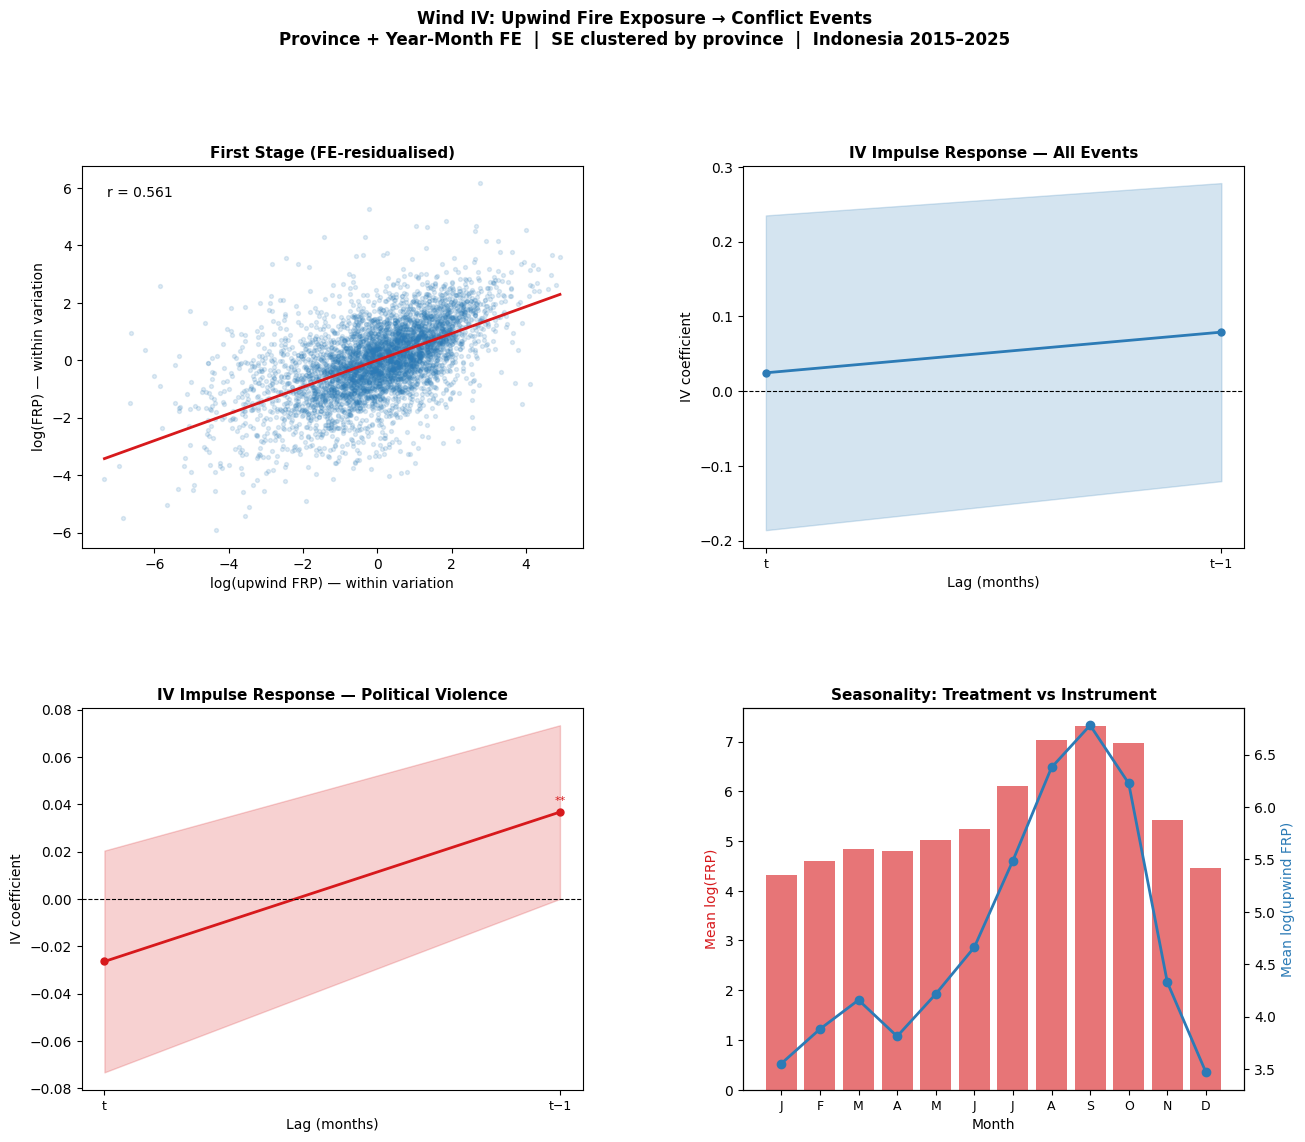

Saved: iv_results.png


In [11]:
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

# Plot 1: First-stage scatter
ax1 = axes[0]
p = panel.copy()
for col in ['log_frp','log_upwind_frp']:
    p[f'{col}_dm'] = (p[col]
        - p.groupby('admin1')[col].transform('mean')
        - p.groupby('year_month')[col].transform('mean')
        + p[col].mean())
ax1.scatter(p['log_upwind_frp_dm'], p['log_frp_dm'], alpha=0.15, s=8, color='#2c7bb6')
m, b = np.polyfit(p['log_upwind_frp_dm'], p['log_frp_dm'], 1)
xr = np.linspace(p['log_upwind_frp_dm'].min(), p['log_upwind_frp_dm'].max(), 100)
ax1.plot(xr, m*xr+b, color='#d7191c', linewidth=2)
ax1.set_xlabel('log(upwind FRP) — within variation', fontsize=10)
ax1.set_ylabel('log(FRP) — within variation', fontsize=10)
ax1.set_title('First Stage (FE-residualised)', fontsize=11, fontweight='bold')
corr = p['log_upwind_frp_dm'].corr(p['log_frp_dm'])
ax1.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=10)

# Plots 2-3: IV impulse responses
for idx, (ax, model_label) in enumerate(zip(axes[1:3], ['IV-1: All events (distributed lags)', 'IV-2: Political violence (distributed lags)'])):
    if model_label in iv_results:
        res = iv_results[model_label]
        tidy = res.tidy().reset_index()
        tidy = tidy[tidy['Coefficient'].str.startswith('log_frp')].copy()
        tidy['lag'] = tidy['Coefficient'].str.extract(r'_l(\d+)$').fillna('0').astype(int)
        tidy = tidy.sort_values('lag')
        lags = tidy['lag'].values
        ests = tidy['Estimate'].values
        lo   = tidy['2.5%'].values
        hi   = tidy['97.5%'].values
        color = '#d7191c' if 'violence' in model_label.lower() else '#2c7bb6'
        ax.fill_between(lags, lo, hi, alpha=0.2, color=color)
        ax.plot(lags, ests, 'o-', color=color, linewidth=2, markersize=5)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(lags)
        ax.set_xticklabels(['t' if l==0 else f't−{l}' for l in lags], fontsize=9)
        for l, e, pv in zip(lags, ests, tidy['Pr(>|t|)'].values):
            star = '***' if pv<0.01 else ('**' if pv<0.05 else ('*' if pv<0.1 else ''))
            if star: ax.annotate(star,(l,e),xytext=(0,6),textcoords='offset points',ha='center',fontsize=8,color=color)
    ax.set_xlabel('Lag (months)', fontsize=10)
    ax.set_ylabel('IV coefficient', fontsize=10)
    ax.set_title('IV Impulse Response — ' + ('All Events' if 'All' in model_label else 'Political Violence'), fontsize=11, fontweight='bold')

# Plot 4: Seasonality
ax4 = axes[3]
monthly = panel.groupby('month').agg(
    frp_mean=('log_frp','mean'),
    iv_mean=('log_upwind_frp','mean')
).reset_index()
ax4b = ax4.twinx()
ax4.bar(monthly['month'], monthly['frp_mean'], color='#d7191c', alpha=0.6, label='log(FRP) — treatment')
ax4b.plot(monthly['month'], monthly['iv_mean'], 'o-', color='#2c7bb6', linewidth=2, label='log(upwind FRP) — instrument')
ax4.set_xlabel('Month', fontsize=10)
ax4.set_ylabel('Mean log(FRP)', fontsize=10, color='#d7191c')
ax4b.set_ylabel('Mean log(upwind FRP)', fontsize=10, color='#2c7bb6')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=9)
ax4.set_title('Seasonality: Treatment vs Instrument', fontsize=11, fontweight='bold')

fig.suptitle(
    'Wind IV: Upwind Fire Exposure → Conflict Events\n'
    'Province + Year-Month FE  |  SE clustered by province  |  Indonesia 2015–2025',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('iv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: iv_results.png')

## 11. Save outputs

In [12]:
panel.to_csv('iv_panel.csv', index=False)
instrument_df.to_csv('upwind_instrument.csv', index=False)

if iv_coef_rows:
    iv_coef_df.to_csv('iv_lag_coefs.csv', index=False)

print('Saved:')
print('  iv_panel.csv           — full province-month panel with instrument')
print('  upwind_instrument.csv  — upwind FRP instrument values')
print('  iv_lag_coefs.csv       — IV distributed lag coefficients')
print('  iv_results.png         — diagnostic and impulse response plots')

Saved:
  iv_panel.csv           — full province-month panel with instrument
  upwind_instrument.csv  — upwind FRP instrument values
  iv_lag_coefs.csv       — IV distributed lag coefficients
  iv_results.png         — diagnostic and impulse response plots
